# **Binary Model**

## Libraries

In [4]:
# Libraries
import sys
import os
import re
import random
import shutil
import math

import pandas as pd
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.preprocessing.image import load_img, img_to_array, smart_resize, ImageDataGenerator

from tensorflow.keras.applications.efficientnet import EfficientNetB0
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Input, BatchNormalization, Dropout
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.metrics import AUC
from focal_loss import BinaryFocalLoss

import optuna

from deep.constants import DATA_DIR, IMAGE_DIR
from deep.preprocessing.oversampler import compute_effective_class_weights

In [ ]:
# Setting options
pd.set_option('display.max_rows', None)

## Data Loading

In [ ]:
# Load the metadata
df = pd.read_csv(f'{DATA_DIR}/metadata.csv')

# Load the IsAnimal data
label = pd.read_csv(f'{DATA_DIR}/binary_labels.csv')

# Join the two dataframes
data = pd.merge(
    df
    ,label
    ,left_on='rare_species_id'
    ,right_on='image_id'
    ,how='inner'
).drop(columns=['rare_species_id', 'image_id'])

In [ ]:
# # Creating a sample
# train_df, sample_df = train_test_split(
#     data,
#     test_size=0.3,
#     stratify=data['family'],
#     random_state=20
# )

## Data Preprocessing

In [ ]:
# Performing the splits
train_df, test_df = train_test_split(data, test_size=0.2, stratify=data['label'], random_state=20)  # Create test set
train_df, val_df = train_test_split(train_df, test_size=0.15, stratify=train_df['label'], random_state=20)  # Create validation set

In [ ]:
# # Encoding the target
# enc = LabelEncoder()

# train_df['family'] = enc.fit_transform(train_df['family'])
# val_df['family'] = enc.transform(val_df['family'])
# test_df['family'] = enc.transform(test_df['family'])

In [ ]:
# Image resizing target dimensions
IMG_SIZE = 224
BATCH_SIZE = 8

In [ ]:
def smart_resize_img(image, target_size=(IMG_SIZE, IMG_SIZE)):
    resized_img = smart_resize(image, target_size)  # Resize image
    resized_img /= 255.0  # Normalize the image
    
    return resized_img

In [ ]:
# # Resizing the images
# label_train_generator = smart_resize_generator(train_df, 'label', batch_size=BATCH_SIZE, target_size=(IMG_SIZE, IMG_SIZE))
# print('train resizing completed')
# label_val_generator = smart_resize_generator(val_df, 'label', batch_size=BATCH_SIZE, target_size=(IMG_SIZE, IMG_SIZE))
# print('validation resizing completed')
# label_test_generator = smart_resize_generator(test_df, 'label', batch_size=BATCH_SIZE, target_size=(IMG_SIZE, IMG_SIZE))
# print('test resizing completed')

In [ ]:
# # Transformation functions
# def rotate_right(img): return img.rotate(-90, expand=True)
# def rotate_left(img): return img.rotate(90, expand=True)
# def flip_horizontal(img): return ImageOps.mirror(img)
# def shear(img):
#     shear_transform = transforms.RandomAffine(degrees=0, shear=20)
#     return shear_transform(img)
# def zoom(img):
#     zoom_transform = transforms.RandomAffine(degrees=0, scale=(0.8, 1.5))
#     return zoom_transform(img)


# transformations = {
#     "rotate_right": rotate_right,
#     "rotate_left": rotate_left,
#     "flip": flip_horizontal,
#     # "shear": shear,
#     # "zoom": zoom
# }

# def augment_images(df, output_dir, target_per_class):
#     os.makedirs(output_dir, exist_ok=True)
#     class_counts = df['label'].value_counts()
#     max_count = class_counts.max()

#     # Identify minority classes
#     minority_classes = class_counts[class_counts < max_count].index

#     # List to hold new rows for augmented images
#     augmented_rows = []

#     for label in minority_classes:
#         class_df = df[df['label'] == label]
#         num_to_generate = target_per_class

#         if num_to_generate <= 0:
#             continue

#         label_dir = os.path.join(output_dir, str(label))
#         os.makedirs(label_dir, exist_ok=True)

#         for _ in range(num_to_generate):
#             row = class_df.sample(1).iloc[0]
#             img_path = row['file_path']
#             original_name = img_path[:-4]
#             ext = img_path[-4:]

#             try:
#                 img = Image.open(f'{IMAGE_DIR}/{img_path}')  # .convert('RGB')
#             except Exception as e:
#                 print(f"Error loading {img_path}: {e}")
#                 continue

#             # Apply random transformation
#             transform_name, transform_fn = random.choice(list(transformations.items()))
#             new_img = transform_fn(img)
#             new_filename = f"{original_name}_{transform_name}{ext}"
#             new_img_path = new_filename
#             new_img.save(f'{IMAGE_DIR}/{new_filename}')

#             # Create a new row for the augmented image and append it to augmented_rows
#             new_row = row.copy()
#             new_row['file_path'] = new_img_path  # Update the file path to the new image
#             augmented_rows.append(new_row)

#     # Add augmented rows to the original dataframe
#     augmented_df = pd.DataFrame(augmented_rows)
#     updated_df = pd.concat([df, augmented_df], ignore_index=True)

#     return updated_df

In [ ]:
# # Clean created images
# for filename in os.listdir(IMAGE_DIR):
#     # Check if there's any letter in the filename
#     if re.search(r'[a-zA-Z]', filename[:-4]):
#         file_path = os.path.join(IMAGE_DIR, filename)
#         if os.path.isfile(file_path):
#             os.remove(file_path)
#             print(f"Deleted: {file_path}")

Deleted: ../data/image_directory/20315204_46561012_noanimalcrop.jpg
Deleted: ../data/image_directory/20124498_46570095_noanimalcrop.jpg
Deleted: ../data/image_directory/30053716_912805_noanimalcrop.jpg
Deleted: ../data/image_directory/28895411_319982_noanimalcrop.jpg
Deleted: ../data/image_directory/28264284_46561012_noanimalcrop.jpg
Deleted: ../data/image_directory/21232818_1033999_noanimalcrop.jpg
Deleted: ../data/image_directory/12853737_449393_noanimalcrop.jpg
Deleted: ../data/image_directory/29548208_47043290_noanimalcrop.jpg
Deleted: ../data/image_directory/20969394_793083_noanimalcrop.jpg
Deleted: ../data/image_directory/29369182_323726_noanimalcrop.jpg
Deleted: ../data/image_directory/20599608_45513966_noanimalcrop.jpg
Deleted: ../data/image_directory/21252576_7250886_noanimalcrop.jpg
Deleted: ../data/image_directory/29658536_45510188_noanimalcrop.jpg


In [ ]:
## Create augmented images
# updated_df = augment_images(train_df, output_dir=IMAGE_DIR, target_per_class=6500)

In [ ]:
def show_augmented_images(generator, num_images=8):
    images, labels = next(generator)

    actual_num = min(num_images, len(images))  # Avoid index errors

    max_cols = 4
    rows = math.ceil(actual_num / max_cols)
    plt.figure(figsize=(max_cols * 3, rows * 3))

    for i in range(actual_num):
        plt.subplot(rows, max_cols, i + 1)
        plt.imshow(images[i])
        plt.axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
# # Undersampling the animal images
# class_0_df = train_df[train_df['label'] == 0]
# class_1_df = train_df[train_df['label'] == 1]

# # Downsample class 1 to 1500
# class_1_downsampled = class_1_df.sample(n=1500, random_state=20)

# # Combine them back
# balanced_train_df = pd.concat(
#     [class_0_df, class_1_downsampled]
# ).sample(
#     frac=1.0
#     ,random_state=20
# ).reset_index(drop=True)

In [ ]:
train_datagen = ImageDataGenerator(
    rotation_range=90,
    shear_range=0.2,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True,
    channel_shift_range=30.0,
    zoom_range=(0.8, 1.2),
    preprocessing_function=smart_resize_img
)
test_datagen = ImageDataGenerator(preprocessing_function=smart_resize_img)

# Train generator
binary_train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=f'{IMAGE_DIR}',
    x_col='file_path',
    y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='raw',
    shuffle=True  # shuffle for training
)

# Validation generator
binary_val_generator = test_datagen.flow_from_dataframe(
    dataframe=val_df,
    directory=f'{IMAGE_DIR}',
    x_col='file_path',
    y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='raw',
    shuffle=False
)

# Test generator
binary_test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    directory=f'{IMAGE_DIR}',
    x_col='file_path',
    y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='raw',
    shuffle=False
)

Found 8149 validated image filenames.
Found 1439 validated image filenames.
Found 2398 validated image filenames.


I0000 00:00:1744918738.154541   34181 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1744918738.188430   34181 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1744918738.188740   34181 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1744918738.189840   34181 cuda_executor.cc:1015] successful NUMA node read from SysFS ha

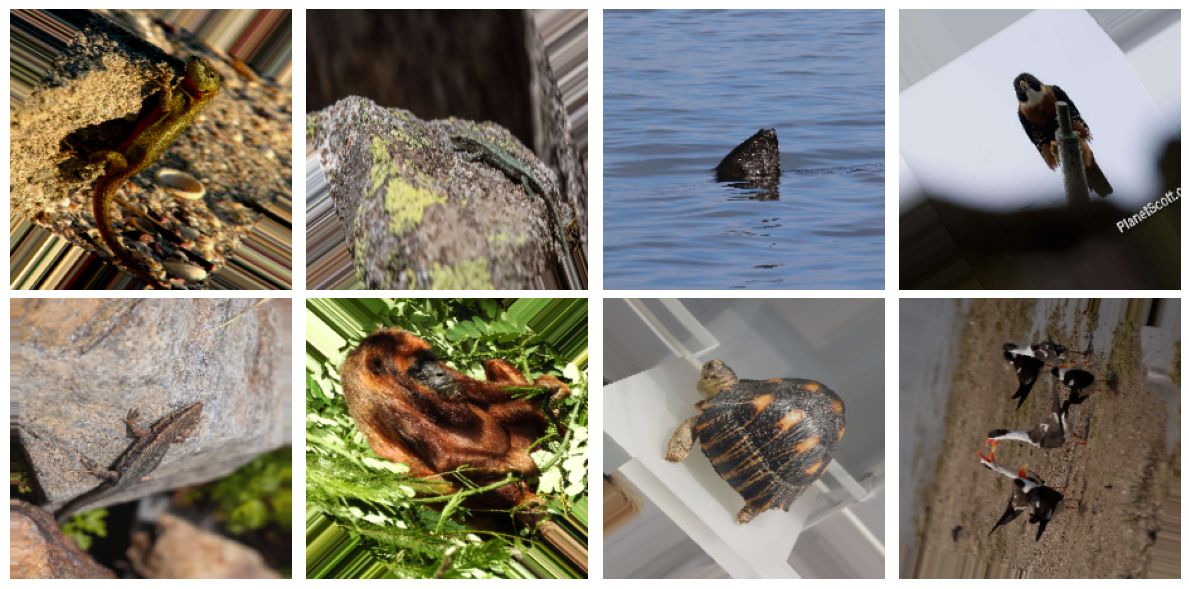

In [ ]:
# Show augmented images - rerun for new batch
show_augmented_images(binary_train_generator, num_images=BATCH_SIZE)

## Modelling

In [ ]:
## Optuna
# def objective(trial):
#     """
#     Objective function for Optuna hyperparameter optimization.
    
#     Args:
#     - trial (optuna.trial.Trial): The trial object used to sample hyperparameters.
    
#     Returns:
#     - float: The evaluation metric (validation accuracy or other).
#     """
#     lr = trial.suggest_float("lr", 1e-6, 1e-1)
#     optimizer_type = trial.suggest_categorical("optimizer", ["adam", "sgd"])
#     patience = trial.suggest_int("patience", 1, 3)
#     lr_factor = trial.suggest_float("lr_factor", 0.1, 0.7)
#     lr_patience = trial.suggest_int("lr_patience", 1, 5)

#     # Set the input
#     input_tensor = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

#     # Load the pre-trained model
#     base_model = EfficientNetB0(include_top=False, weights='imagenet', input_tensor=input_tensor)

#     # Add necessary layers
#     x = GlobalAveragePooling2D()(base_model.output)
#     output = Dense(1, activation='sigmoid')(x)  # Binary classification

#     binary_model = Model(inputs=input_tensor, outputs=output)

#     # Optimizer setup based on dynamic 'optimizer_type'
#     if optimizer_type == "adam":
#         optimizer = Adam(learning_rate=lr)
#     elif optimizer_type == "sgd":
#         optimizer = SGD(learning_rate=lr)
#     else:
#         raise ValueError(f"Unknown optimizer type: {optimizer_type}")
    
#     # Compiling the model
#     binary_model.compile(
#         optimizer=optimizer,
#         loss='binary_crossentropy',
#         metrics=['accuracy', 'precision', 'recall']
#     )

#     # Fit the model
#     binary_model.fit(
#         binary_train_generator,
#         validation_data=binary_val_generator,
#         epochs=5,
#         steps_per_epoch=int(np.ceil(len(train_df) / BATCH_SIZE)),
#         callbacks=[
#             EarlyStopping(patience=patience, restore_best_weights=True),
#             ReduceLROnPlateau(patience=lr_patience, factor=lr_factor, verbose=1)
#         ],
#         verbose=1
#     )

#     # Evaluate the model using the  validation set
#     _, val_accuracy, _, _ = binary_model.evaluate(binary_val_generator, verbose=0)
    
#     # Return the validation accuracy as the objective metric
#     return val_accuracy

In [ ]:
# # Create a study
# study = optuna.create_study(direction="maximize")

# # Optimize the objective function
# study.optimize(lambda trial: objective(trial), n_trials=3)

# # Get the best trial's hyperparameters
# print(f"Best trial: {study.best_trial.params}")

In [ ]:
# Build the model

# Set the input
input_tensor = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

# Load the pre-trained model
base_model = EfficientNetB0(include_top=False, weights='imagenet', input_tensor=input_tensor)
# Freeze layers
base_model.trainable = False

# Add top layers
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(128, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)  # Binary classification

binary_model = Model(inputs=input_tensor, outputs=output)

In [ ]:
# Compute class weights
class_weights = compute_effective_class_weights(train_df, 'label')

{0.0: 1.3911292340090886, 1.0: 0.6088707659909114}


In [ ]:
# Compiling the model
binary_model.compile(
    optimizer=Adam(learning_rate=0.01)
    ,loss=BinaryFocalLoss(
        gamma=2
        ,pos_weight=class_weights[1] / (class_weights[0] + class_weights[1])
    )
    # ,loss='binary_crossentropy'
    ,metrics=['accuracy', AUC(), 'precision', 'recall']
)

In [ ]:
# Fit the model
fitted_binary = binary_model.fit(
    binary_train_generator
    ,validation_data=binary_val_generator
    ,epochs=5
    ,steps_per_epoch=int(np.ceil(len(train_df) / BATCH_SIZE))
    ,class_weight=class_weights
    ,callbacks=[
        EarlyStopping(patience=3, restore_best_weights=True)
        ,ReduceLROnPlateau(patience=2, factor=0.5, verbose=1)
    ]
    ,verbose=1
)

/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5


I0000 00:00:1744918750.006015   34247 service.cc:146] XLA service 0x74797804fdc0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1744918750.006038   34247 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce MX350, Compute Capability 6.1
2025-04-17 20:39:10.313202: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-04-17 20:39:11.544886: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 90100


   1/1019 ━━━━━━━━━━━━━━━━━━━━ 6:07:25 22s/step - accuracy: 0.2500 - auc: 0.0000e+00 - loss: 0.0689 - precision: 0.6667 - recall: 0.2857

I0000 00:00:1744918763.354342   34247 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


  87/1019 ━━━━━━━━━━━━━━━━━━━━ 8:26 544ms/step - accuracy: 0.6494 - auc: 0.4655 - loss: 0.0983 - precision: 0.9258 - recall: 0.6745

/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/PIL/Image.py:3402: DecompressionBombWarning: Image size (115600000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


1019/1019 ━━━━━━━━━━━━━━━━━━━━ 540s 509ms/step - accuracy: 0.7956 - auc: 0.4728 - loss: 0.0554 - precision: 0.9284 - recall: 0.8452 - val_accuracy: 0.9291 - val_auc: 0.5386 - val_loss: 0.0486 - val_precision: 0.9291 - val_recall: 1.0000 - learning_rate: 0.0100
Epoch 2/5
1019/1019 ━━━━━━━━━━━━━━━━━━━━ 481s 472ms/step - accuracy: 0.9144 - auc: 0.4881 - loss: 0.0450 - precision: 0.9306 - recall: 0.9813 - val_accuracy: 0.9291 - val_auc: 0.4989 - val_loss: 0.0488 - val_precision: 0.9291 - val_recall: 1.0000 - learning_rate: 0.0100
Epoch 3/5
1019/1019 ━━━━━━━━━━━━━━━━━━━━ 0s 411ms/step - accuracy: 0.9208 - auc: 0.4887 - loss: 0.0465 - precision: 0.9263 - recall: 0.9936
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.004999999888241291.
1019/1019 ━━━━━━━━━━━━━━━━━━━━ 483s 474ms/step - accuracy: 0.9208 - auc: 0.4887 - loss: 0.0465 - precision: 0.9263 - recall: 0.9936 - val_accuracy: 0.9291 - val_auc: 0.5000 - val_loss: 0.0517 - val_precision: 0.9291 - val_recall: 1.0000 - learning_rate:

In [ ]:
# Get the average from model metrics
history = fitted_binary.history
average_metrics = {metric: np.mean(values) for metric, values in history.items()}

for metric, avg in average_metrics.items():
    print(f"{metric}: {avg:.4f}")

accuracy: 0.9029
auc: 0.4921
loss: 0.0459
precision: 0.9293
recall: 0.9692
val_accuracy: 0.9291
val_auc: 0.5094
val_loss: 0.0501
val_precision: 0.9291
val_recall: 1.0000
learning_rate: 0.0087


In [ ]:
# # Export the model
# binary_model.save('../models/binary_model.keras')

In [ ]:
# # Load the model
# binary_model = load_model('../models/binary_model.keras')

In [ ]:
# Make predictions
predictions = binary_model.predict(
    binary_test_generator
    ,steps=len(binary_test_generator)
    ,verbose=1
)

300/300 ━━━━━━━━━━━━━━━━━━━━ 117s 373ms/step


In [ ]:
# Get the true labels
y_true = binary_test_generator.labels

# Convert predictions to class labels
y_pred = (predictions > 0.5).astype(int).flatten()

# Calculate metrics
print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
print(f"Precision: {precision_score(y_true, y_pred):.4f}")
print(f"Recall: {recall_score(y_true, y_pred):.4f}")

Accuracy: 0.9295
Precision: 0.9295
Recall: 1.0000


In [ ]:
# Get unique values and their counts
unique, counts = np.unique(y_pred, return_counts=True)

# Display the result
value_counts = dict(zip(unique, counts))
print(value_counts)

{1: 2398}


In [ ]:
# # Save the predictions
# file_paths = binary_test_generator.filenames
# pred_df = pd.DataFrame({
#     'file_path': file_paths,
#     'predictions': (predictions > 0.5).astype(int).flatten()
# })

# # Export to csv
# # pred_df.to_csv('../models/binary_predictions.csv', index=False)